In [1]:
from src.extract_features import *
from src.plotting import plot_sample_distributions, combine_plots, plot_dmr_manhattan_interactive
from src.cfdna_methylkit import *
from src.cfdna_methylkit_regions import *
import os
import pandas as pd
from pathlib import Path

In [2]:
bam_files = os.listdir("/Users/tatarakis/data/celfie/bam/")
bam_files = [f for f in bam_files if f.endswith(".bam")]
bam_file_paths = [str(Path("/Users/tatarakis/data/celfie/bam/") / f) for f in bam_files]

sample_meta = pd.read_csv("/Users/tatarakis/data/celfie/celfie_cfDNA_ss.csv")
samples = sample_meta['Run'].tolist()

stats = {}

for sample in samples:
    bam_path = str(Path("/Users/tatarakis/data/celfie/bam/") / f"{sample}.deduplicated.sorted_ds10mill_chr21.bam")
    stat = aggregate_features_from_bam(bam_path)
    stats[sample] = stat

# Fragment length and fragment end motif distribution

In [3]:
%%capture
ctrl_plots = []
als_plots = []

for sample in samples:
    plot = plot_sample_distributions(stats[sample], sample_name=sample)
    if sample_meta[sample_meta["Run"] == sample]["disease_status"].values[0] == "als":
        als_plots.append(plot)
    else:
        ctrl_plots.append(plot)





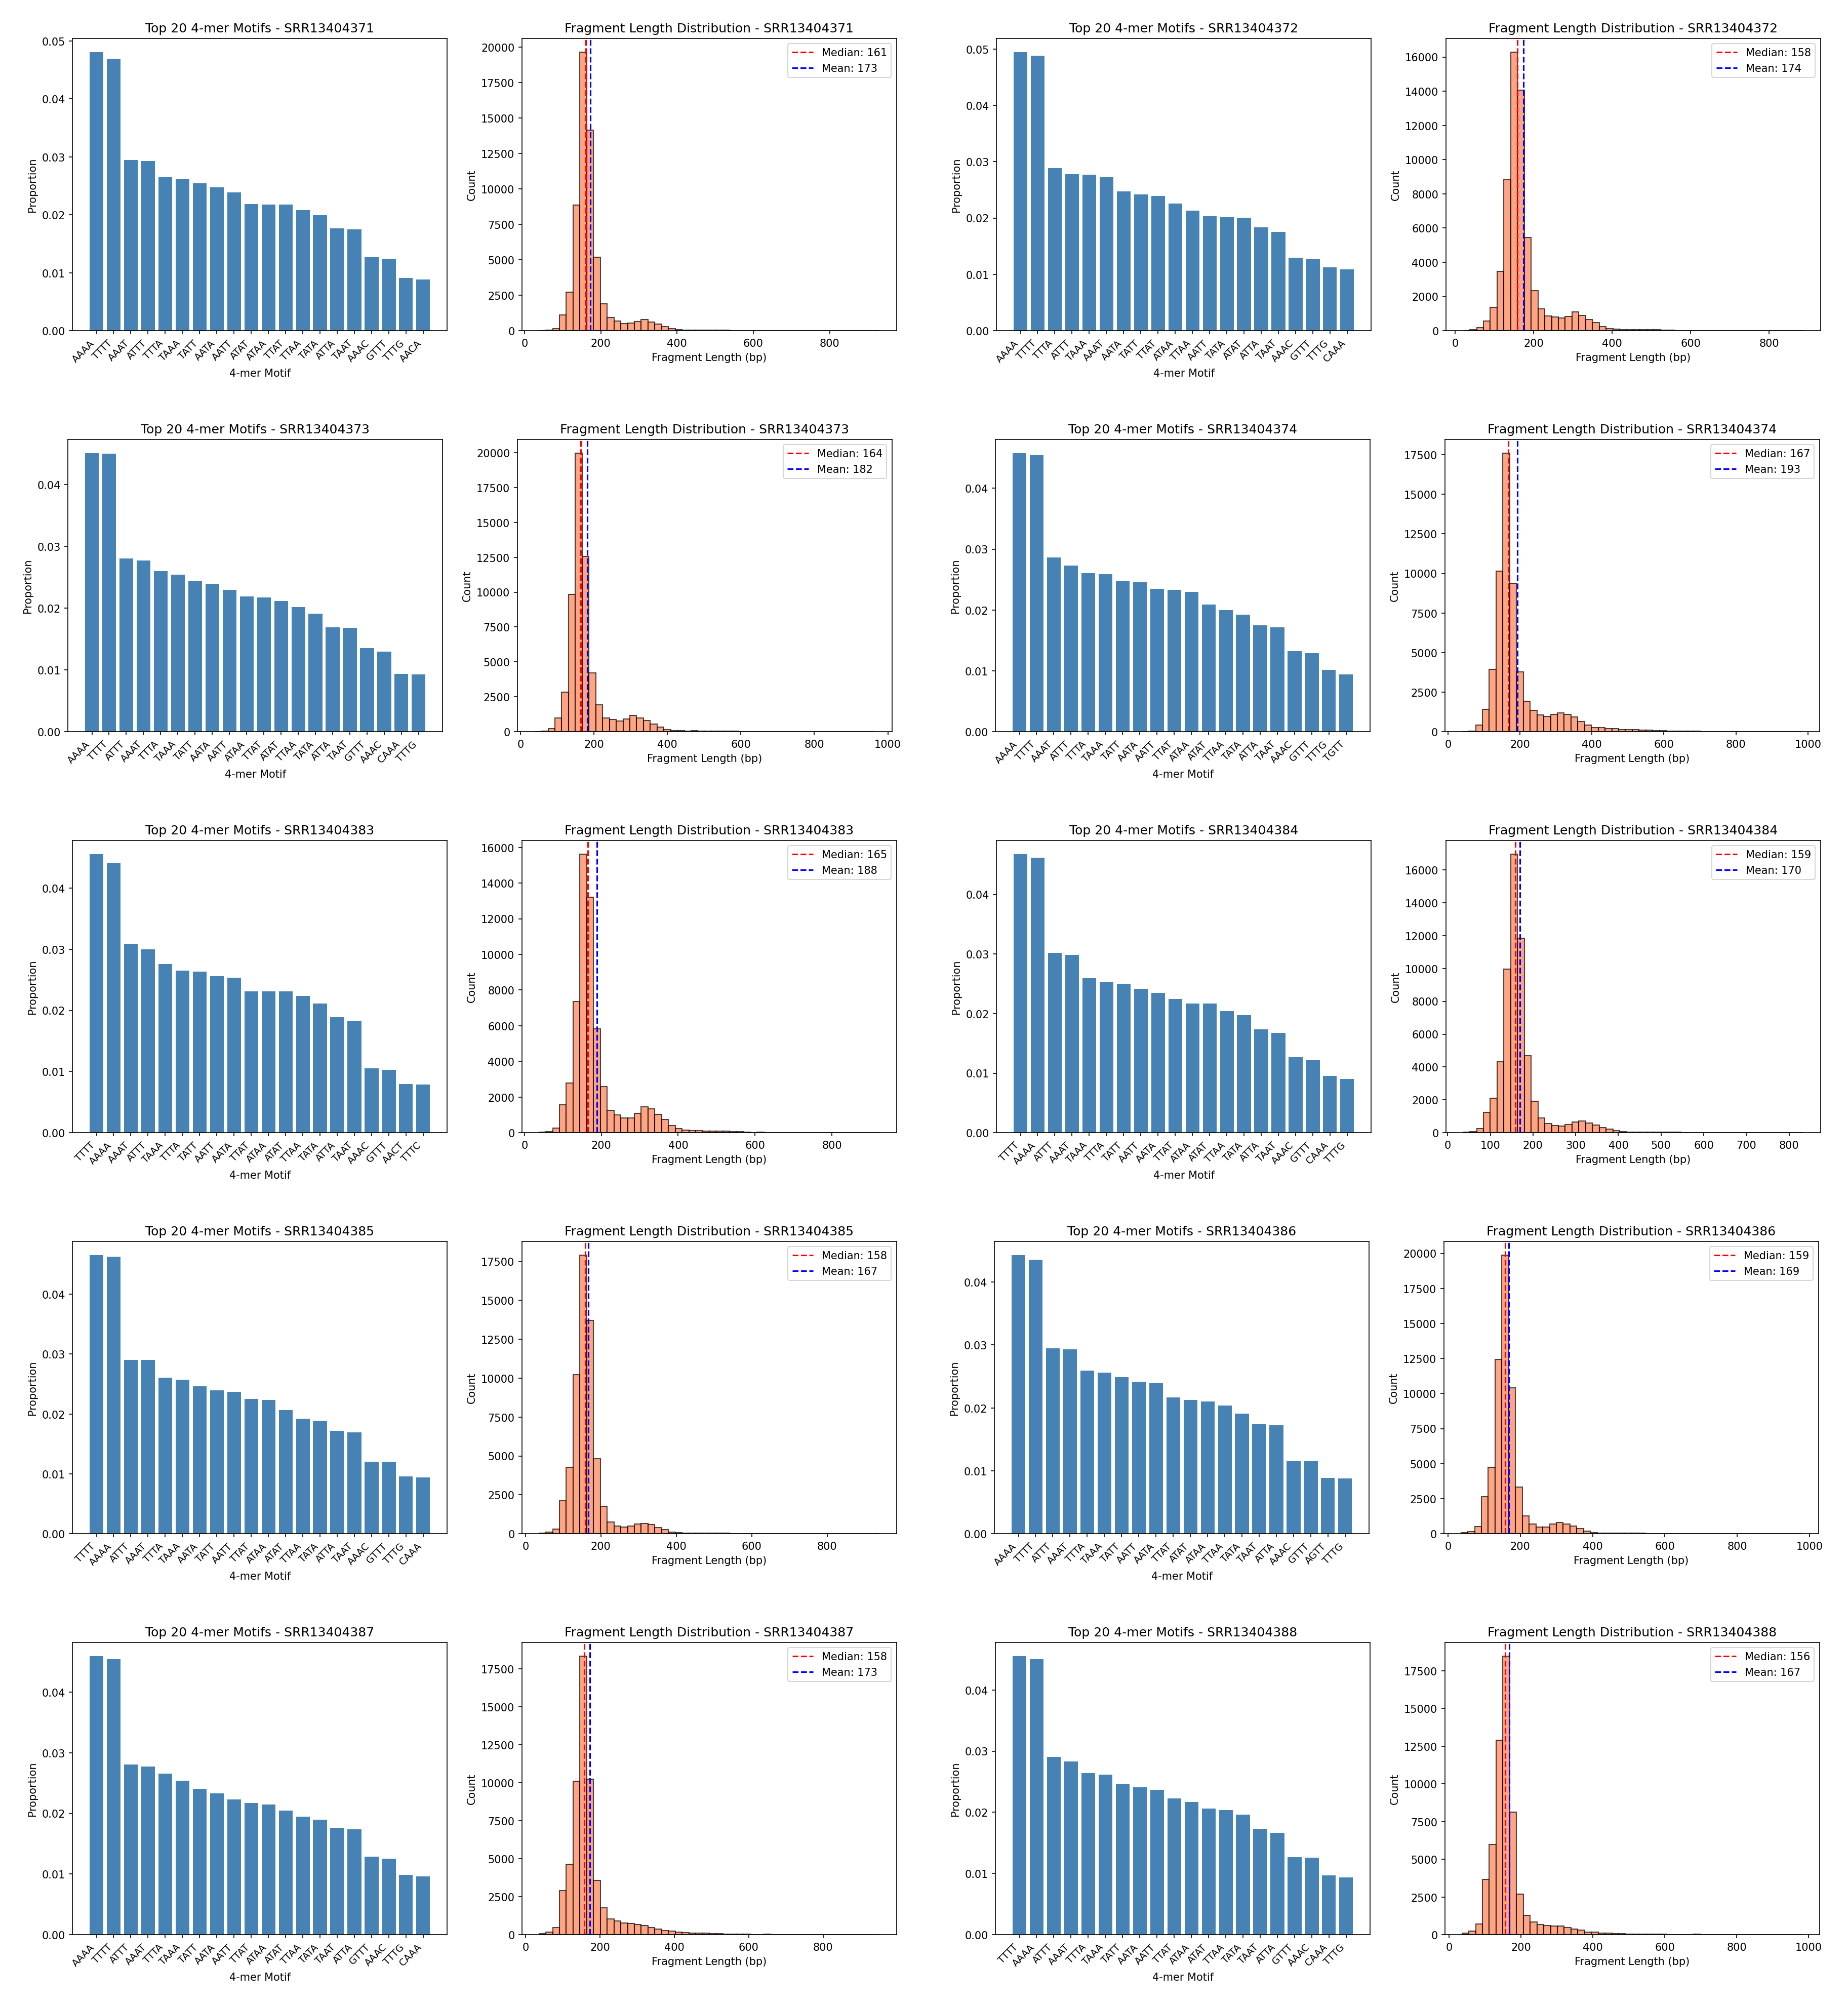

In [4]:
combine_plots(ctrl_plots, cols=2)

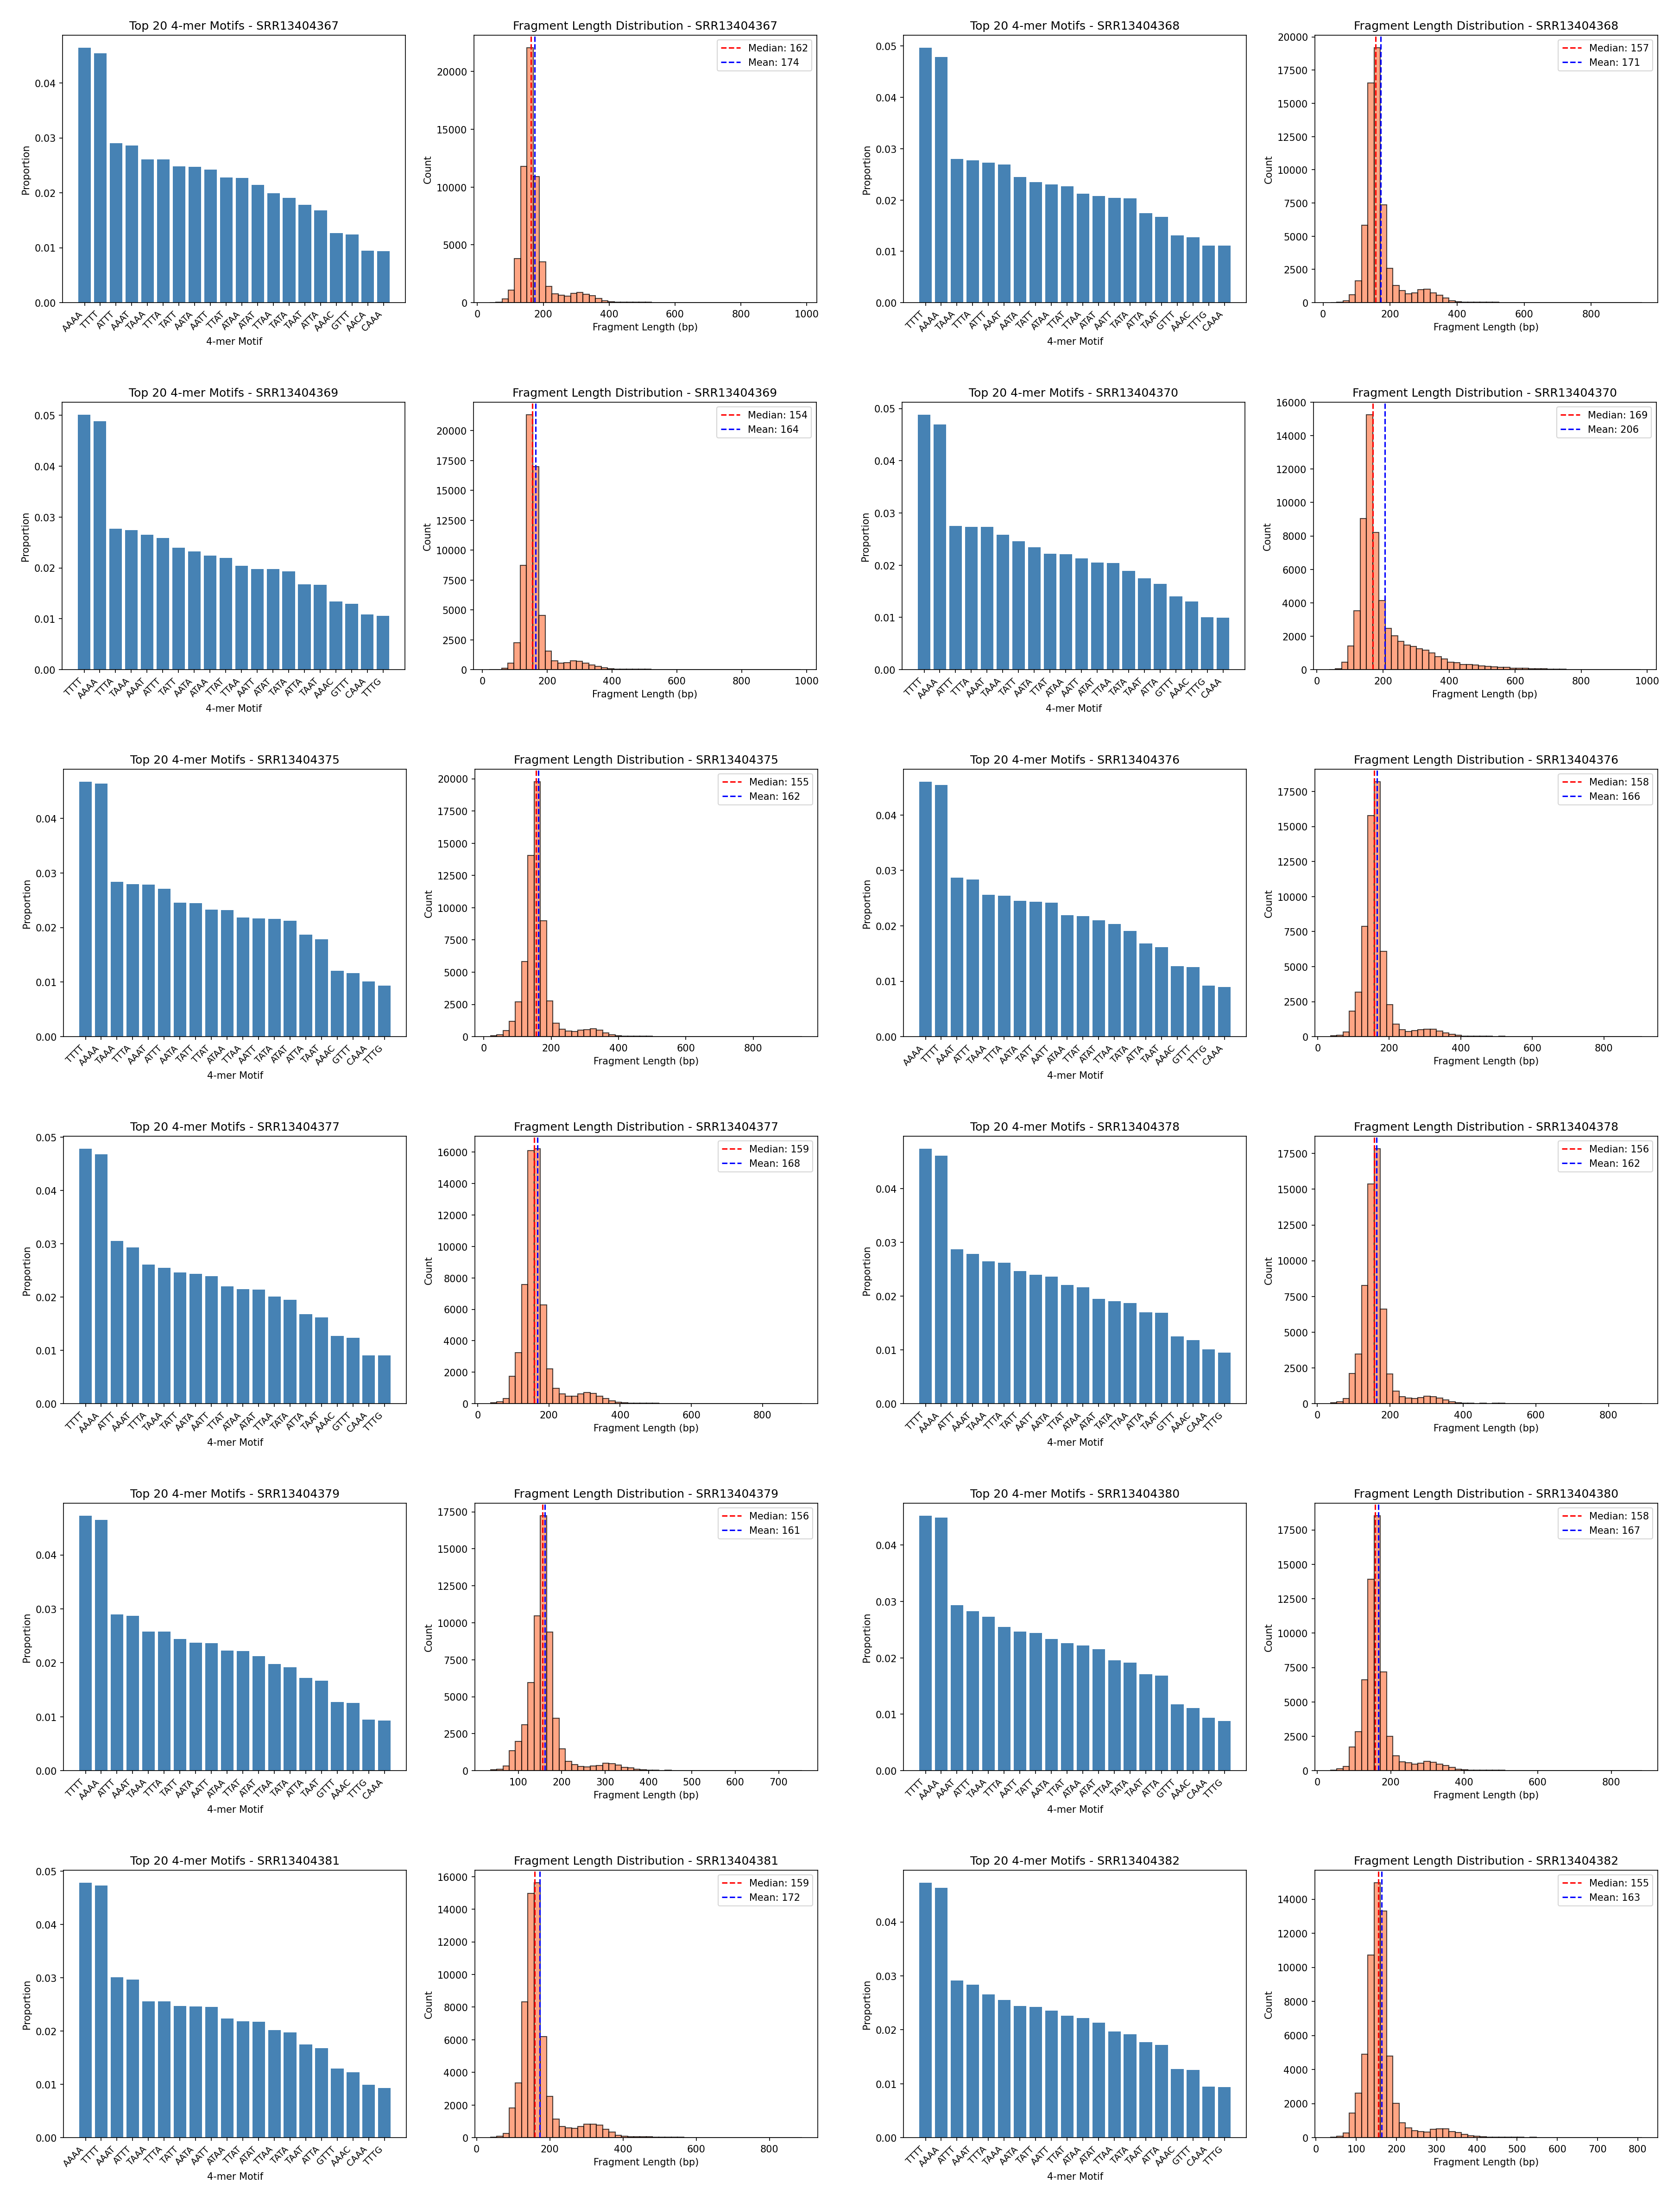

In [5]:
combine_plots(als_plots, cols=2)

# Methylation analysis

We will extract methylation information for each base pair using the XM tag in the Bismark alignment files.

In [6]:
# extract per site methylation
methylation_data = {}
for sample in samples:
    bam_path = str(Path("/Users/tatarakis/data/celfie/bam/") / f"{sample}.deduplicated.sorted_ds10mill_chr21.bam")
    methylation_df = extract_methylation_by_position(bam_path, context="all")
    methylation_data[sample] = methylation_df

In [ ]:
methylation_data["SRR13404367"].head()

,chrom,position,meth_count,unmeth_count,total,meth_rate
0,chr21,5033452,0,1,1,0.0
1,chr21,5033453,1,0,1,1.0
2,chr21,5033462,0,1,1,0.0
3,chr21,5033465,0,1,1,0.0
4,chr21,5033471,0,1,1,0.0
...,...,...,...,...,...,...
1591800,chr21,46699592,1,0,1,1.0
1591801,chr21,46699597,0,1,1,0.0
1591802,chr21,46699600,0,1,1,0.0
1591803,chr21,46699603,1,0,1,1.0


If we look at the coverage per base pair within a sample, we can see that the vast majority of sites are captured only once. This means that for any given methylation event, we essentially have a binary. This does not lend itself well to differential methylation analysis.

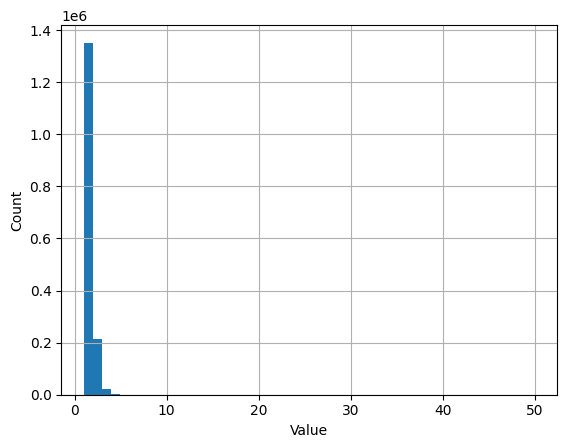

In [8]:
import matplotlib.pyplot as plt
methylation_data["SRR13404367"]['total'].hist(bins=50)
plt.xlabel('Value')
plt.ylabel('Count')
plt.show()

However, what we can do is aggregate methylation signal across regions. For our purposes here, we will use preannotated CpG islands (regions known to be prone to CpG methylation) and perform differential anlysis using those.

In [9]:
%%capture
# convert BAM files to methylkit format
methylkit_files = []
for sample in samples:
    bam_path = str(Path("/Users/tatarakis/data/celfie/bam/") / f"{sample}.deduplicated.sorted_ds10mill_chr21.bam")
    methylkit_path = str(Path("/Users/tatarakis/data/celfie/methylkit/") / f"{sample}_methylkit.txt")
    export_bam_to_methylkit_format(bam_path, methylkit_path, sample_id=sample)
    methylkit_files.append(methylkit_path)

In [10]:
%%capture
# export bam files to coverage files
coverage_files = []
for sample in samples:
    bam_path = str(Path("/Users/tatarakis/data/celfie/bam/") / f"{sample}.deduplicated.sorted_ds10mill_chr21.bam")
    coverage_path = str(Path("/Users/tatarakis/data/celfie/coverage/") / f"{sample}_coverage.txt")
    export_bam_to_bismark_coverage(bam_path, coverage_path)
    coverage_files.append(coverage_path)

In [11]:
%%capture

import rpy2.robjects as ro

# Install BiocManager and methylKit directly from Python
ro.r('''
    if (!requireNamespace("BiocManager", quietly = TRUE))
        install.packages("BiocManager", repos="https://cloud.r-project.org")

    if (!requireNamespace("methylKit", quietly = TRUE))
        BiocManager::install("methylKit", ask=FALSE, update=FALSE)
''')

In [12]:
# Verify installation
from rpy2.robjects.packages import importr

# Test: Import methylKit
try:
    methylkit = importr('methylKit')
    print("✓ methylKit imported successfully")
except Exception as e:
    print(f"✗ Failed to import methylKit: {e}")

✓ methylKit imported successfully


In [13]:
sample_meta["disease_binary"] = sample_meta["disease_status"].apply(lambda x: 1 if x == "als" else 0)

In [14]:
# create a binary from the disease states for DMR
disease = sample_meta["disease_binary"].values.tolist()

In [15]:
results = run_methylkit_region_dmr_analysis(
    coverage_files=coverage_files,
    sample_ids=samples,
    treatments=disease,
    regions_bed="data/cpg_islands_chr21.bed",
    region_min_coverage=1,
    min_diff=0.1,
    qvalue=0.05,
    verbose=True
)

# Get results
region_matrix = results['region_matrix']  # Samples x regions matrix for classification
sig_regions = results['regions_significant']  # Significant DMRs
all_regions = results['regions_all']  # All tested regions with stats

print(f"Region matrix shape: {region_matrix.shape}")
print(f"Significant regions: {len(sig_regions)}")

R callback write-console: Received list of locations.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  


Step 1: Reading methylation data...


R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  
R callback write-console: Reading file.
  


Step 2: Loading regions from data/cpg_islands_chr21.bed...
  Loaded 446 regions
Step 3: Aggregating methylation by regions...
Step 4: Filtering regions by coverage...

  Regions per sample after filtering:
    SRR13404367: 98 regions
    SRR13404368: 116 regions
    SRR13404369: 106 regions
    SRR13404370: 170 regions
    SRR13404371: 86 regions
    SRR13404372: 119 regions
    SRR13404373: 91 regions
    SRR13404374: 113 regions
    SRR13404375: 79 regions
    SRR13404376: 94 regions
    SRR13404377: 103 regions
    SRR13404378: 100 regions
    SRR13404379: 93 regions
    SRR13404380: 86 regions
    SRR13404381: 102 regions
    SRR13404382: 122 regions
    SRR13404383: 79 regions
    SRR13404384: 106 regions
    SRR13404385: 99 regions
    SRR13404386: 83 regions
    SRR13404387: 150 regions
    SRR13404388: 119 regions


R callback write-console: uniting...
  
R callback write-console: two groups detected:
 will calculate methylation difference as the difference of
treatment (group: 1) - control (group: 0)
  



Step 5: Normalizing coverage...
Step 6: Merging samples...

  United regions across samples: 290

Step 7: Calculating differential methylation...
Step 8: Extracting results...
Step 9: Exporting methylation matrix...

Results summary:
  Total regions tested: 155
  Significant regions: 30
    Hypermethylated: 14
    Hypomethylated: 16

Results saved to ./methylkit_results
Region matrix shape: (22, 290)
Significant regions: 30


In [16]:
fig = plot_dmr_manhattan_interactive(
    results['regions_all'], 
    sig_threshold=0.05, 
    title = "ALS vs ctrl DMR"
    )
fig.update_layout(width=700, height=600)
fig.show()